# Equality constrained analytic centering

The objective is to maximize the function
$$ f(x) = \sum_{i=1}^{n} -\log(x_i),$$ subject to the equality constraint $$Ax = b,$$ where \(A\) is a matrix and \(b\) is a vector.


We will implement three variations: Equality Constrained Newton Method, Infeasible Start Newton's Method, and Dual Problem Newton Method.

First, let's use cvxpy to solve it.

In [1]:
import cvxpy as cp
import numpy as np

def solve_analytical_centering(A, b):
    n = A.shape[1]  # Number of variables

    # Define the optimization variable
    x = cp.Variable(n)

    # Define the objective function
    objective = cp.Minimize(cp.sum(-cp.log(x)))

    # Define the constraints
    constraints = [A @ x == b]

    # Define the optimization problem and solve it
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.ECOS)

    # Check if the problem was successfully solved
    if problem.status in ["optimal", "optimal_inaccurate"]:
        print("Optimal solution found.")
        return x.value, objective.value
    else:
        print("Problem could not be solved to optimality.")
        return None


In [2]:
# Generate a matrix of rank $m$ and $b$ is a weighted sum of $A$
import numpy as np


def generate_A_b(m, n):
    """
    Generate a matrix A (m x n) with linearly dependent columns and a vector b
    as a random weighted sum of the columns of A.

    Parameters:
    - m: int, the number of rows in A.
    - n: int, the number of columns in A, where n >= m.

    Returns:
    - A: numpy.ndarray, the generated matrix of size (m x n).
    - b: numpy.ndarray, the generated vector of size (m,).
    """
    if n < m:
        raise ValueError("n must be greater than or equal to m.")

    # Start by generating an m x m full-rank matrix
    A = np.random.rand(m, m)
    A_new = A
    # If n > m, extend A to be m x n by adding linear combinations of its first m columns
    if n > m:
        for _ in range(n - m):
            weights = np.random.rand(m)  # Random weights for the linear combination
            new_col = np.dot(A, weights)  # Compute the new column as a dot product
            new_col = new_col.reshape(-1, 1)  # Reshape for hstack
            A_new = np.hstack((A_new, new_col))  # Append the new column to A

    # Generate b as a random weighted sum of the columns of A
    weights_b = np.random.rand(n)  # Corrected to generate a 1D array of weights
    b = np.dot(A_new, weights_b)

    shuffled_indices = np.random.permutation(A_new.shape[1])
    # Apply this permutation to the columns
    A_final = A_new[:, shuffled_indices]

    return A_final, b


In [3]:
m = 10
n = 600

A, b = generate_A_b(m, n)

x_solution, opt_val = solve_analytical_centering(A,b)

print(x_solution)

print(f"optimal solution is {opt_val:.4f}")

Optimal solution found.
[0.46052633 0.628311   0.62062376 0.47006001 0.53914997 0.49452762
 0.57102237 0.6270433  0.42722246 0.44675288 0.48268432 0.66340046
 0.59829172 0.42758705 0.481407   0.51632044 0.53894978 0.61331956
 2.42666817 0.50989812 0.54031989 0.64864437 0.41254852 0.57523161
 0.70675871 0.43723014 0.43674556 0.55302521 0.41088843 0.43540601
 0.44203374 0.49250012 0.45410334 0.43080963 0.6582129  0.53244213
 0.60717328 0.40232175 0.56671652 0.45938166 0.64291264 0.41498917
 0.46023687 0.58239976 0.45201231 0.44954815 0.44601488 0.69554057
 0.58239611 0.49954734 0.45315091 0.45772344 0.41915234 0.45356277
 0.56664313 0.48233289 0.61491649 0.52120642 0.52919107 3.54389417
 0.48420482 0.43739846 0.62994205 0.59441524 0.52658011 0.43116028
 0.42189229 0.40277639 0.6443915  0.367946   0.63502394 0.61309031
 0.39143761 0.37385966 0.57699097 0.43391282 0.64954158 0.60996734
 0.45203765 0.57595312 0.79497906 0.5005733  0.41364665 0.46177297
 0.5038767  0.39056947 0.51818165 0.44



### Equality Constrained Newton Method

In the Equality Constrained Newton Method for solving the given problem, the goal is to maximize the objective function $\sum -\log(x_i)$ subject to the equality constraint $Ax = b$. This method involves finding a step direction $(\delta x, w)$ that respects the equality constraint while moving towards the maximum of the objective function.

The equation solved in each iteration to find the descent direction $(\delta x, w)$ is given by:


\begin{align}
\begin{bmatrix}
\nabla^2 f(x) & A^\top \\
A & 0
\end{bmatrix}
\begin{bmatrix}
\Delta x \\
w
\end{bmatrix}
=
\begin{bmatrix}
- \nabla f(x) \\
0
\end{bmatrix}
\end{align}


Here, $\nabla^2 f(x)$ is the Hessian of the objective function, $A^\top$ is the transpose of the constraint matrix $A$, $\Delta x$ is the Newton step for $x$, and $w$ is the dual variable associated with the equality constraint. $\nabla f(x)$ represents the gradient of the objective function.

The Hessian $\nabla^2 f(x)$ for the objective function $\sum -\log(x_i)$ is a diagonal matrix with entries $\frac{1}{x_i^2}$, and the gradient $\nabla f(x)$ is a vector with entries $-\frac{1}{x_i}$.


#### Initialization
The initialization $x^0$ needs to satisfy $x^0 > 0 $ and $A x^0 = b$.

In [4]:
import numpy as np

def check_feasibility(A, b, x):

    # Check if Ax equals b within a numerical tolerance
    is_equal = np.allclose(A @ x, b)

    # Check if all elements of x are strictly positive
    is_positive = np.all(x > 0)

    # Return True if both conditions are met, False otherwise
    return is_equal, is_positive

def equality_constrained_newton(A, b, x0, num_iters):
    m, n = A.shape
    x = x0
    func_vals = []  # Convergence tracker for the function value

    for _ in range(num_iters):
        # Calculate the gradient and Hessian
        grad_f = -1 / x
        hess_f = np.diag(1 / x**2)

        # Form the KKT matrix
        KKT_matrix = np.block([[hess_f, A.T], [A, np.zeros((m, m))]])
        rhs = np.concatenate([-grad_f, np.zeros(m)])

        # Solve the KKT system
        delta_x_w = np.linalg.solve(KKT_matrix, rhs)
        delta_x = delta_x_w[:n]

        # Update x
        x += delta_x
        is_equal, is_positive = check_feasibility(A,b, x)
        if is_equal == False:
            print("violate equality constraint")
        elif is_positive == False:
            print("out of domain of log")
        else:
            # print("feasible iterate")
            pass

        # Update the convergence tracker
        func_val = -np.sum(np.log(x))
        func_vals.append(func_val)

    return x, func_vals


To initialize $x^0$ for the Equality Constrained Newton Method, we solve an LP.

  
\begin{align}
\min 0  \\
A x  = b \\
 x \geq \epsilon \cdot\mathbf{1}.
\end{align}
 Here $\epsilon $ is set to be very small.


In [5]:
import cvxpy as cp
import numpy as np

def initialize_eq_newton_lp(A, b, epsilon=1e-5):
    # Number of variables
    n = A.shape[1]

    # Define the optimization variable
    x = cp.Variable(n)

    # Define the constraints
    constraints = [A @ x == b, x >= epsilon]

    # Define the objective. Since we're only interested in feasibility,
    # we set it to minimize 0 (a constant objective).
    objective = cp.Minimize(0)

    # Define the problem
    problem = cp.Problem(objective, constraints)

    # Solve the problem
    problem.solve()

    # Check if the problem has a feasible solution
    if problem.status in ["optimal", "optimal_inaccurate"]:
        print("Found a feasible initialization.")
        return x.value  # x.value contains the optimal value for x
    else:
        print("Failed to find a feasible initialization.")
        return None

Let's test this method.



Found a feasible initialization.
(True, True)
Iteration  |       Function Value
---------------------------------
1          |       399.7900639157
2          |       394.5365250557
3          |       391.4988006746
4          |       390.1509985033
5          |       389.8456617159
6          |       389.8237737739
7          |       389.8235814644
8          |       389.8235814399
9          |       389.8235814399
10         |       389.8235814399
11         |       389.8235814399
12         |       389.8235814399
13         |       389.8235814399
14         |       389.8235814399
15         |       389.8235814399
16         |       389.8235814399
17         |       389.8235814399
18         |       389.8235814399
19         |       389.8235814399
20         |       389.8235814399
21         |       389.8235814399
22         |       389.8235814399
23         |       389.8235814399
24         |       389.8235814399
25         |       389.8235814399
26         |       389.8235814399
27

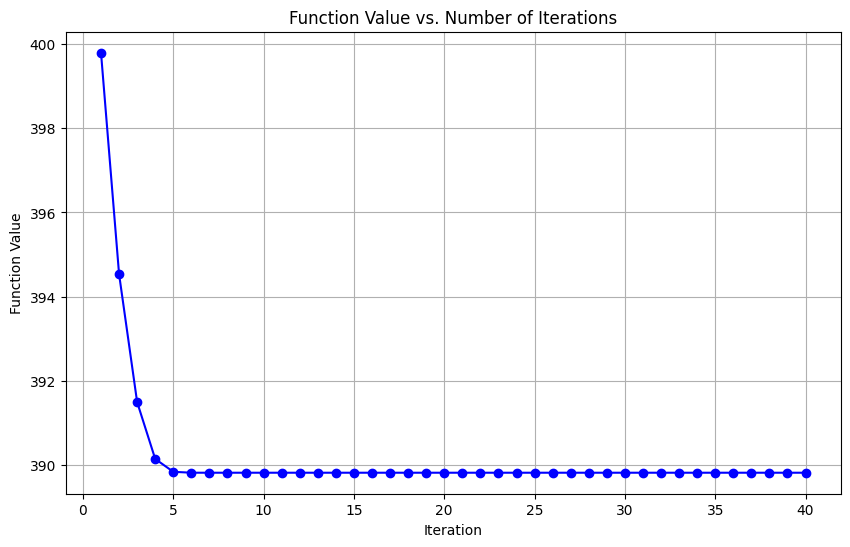

In [6]:
import matplotlib.pyplot as plt

x_0 = initialize_eq_newton_lp(A, b)
print(check_feasibility(A, b, x_0))
# print(x_0)

x_newton, func_vals = equality_constrained_newton(A, b, x_0, 40)

# print(x_newton)

print(f"{'Iteration':<10} | {'Function Value':>20}")

# Print a separator
print("-" * 33)

# Print each iteration index and function value
for index, value in enumerate(func_vals, start=1):
    print(f"{index:<10} | {value:>20.10f}")


print(f"optimal value found by newton method is {func_vals[-1]:.4f}")





# Number of iterations
iterations = list(range(1, len(func_vals) + 1))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(iterations, func_vals, marker='o', linestyle='-', color='b')
plt.title('Function Value vs. Number of Iterations')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.grid(True)
plt.show()


### Infeasible Newton Method

The Infeasible Newton Method is used to solve the optimization problem even when the initial point does not satisfy the equality constraint $Ax = b$. Unlike the Equality Constrained Newton Method, this approach allows for the initial point to be infeasible, aiming to reduce the infeasibility while improving the objective function value. In each iteration, this method solves the following linear system to find the descent direction $(\delta x, \nu)$, where $\nu$ is the Lagrange multiplier for the equality constraint:


\begin{align}
\begin{bmatrix}
\nabla^2 f(x) & A^\top \\
A & 0
\end{bmatrix}
\begin{bmatrix}
\Delta x \\
\nu
\end{bmatrix}
=
\begin{bmatrix}
- \nabla f(x) \\
b - A x
\end{bmatrix}
\end{align}


This system is similar to the one solved in the Equality Constrained Newton Method, but the right-hand side now includes the term $b - Ax$, which represents the current infeasibility of the solution with respect to the equality constraint.

#### Initialization
The initialization $x^0$ needs to satisfy $x^0 > 0 $.

In [7]:
import numpy as np


def infeasible_newton(A, b, x0, num_iters):
    m, n = A.shape
    x = x0
    # Initialize nu arbitrarily, for example, to a vector of zeros
    nu = np.zeros(m)
    residues = []  # Convergence tracker for the norm of residue

    for _ in range(num_iters):
        # Calculate the gradient and Hessian
        grad_f = -1 / x
        hess_f = np.diag(1 / x**2)

        # Calculate the current infeasibility
        current_infeasibility = b - A @ x

        # Form the KKT matrix
        KKT_matrix = np.block([[hess_f, A.T], [A, np.zeros((m, m))]])
        rhs = np.concatenate([-grad_f - A.T @ nu, current_infeasibility])

        # Solve the KKT system for delta_x and delta_nu
        delta_x_nu = np.linalg.solve(KKT_matrix, rhs)
        delta_x = delta_x_nu[:n]
        delta_nu = delta_x_nu[n:]

        # Update x and nu
        stepsize = 0.6
        x += stepsize * delta_x
        nu += stepsize *  delta_nu

        # Update the convergence tracker with the correct residue calculation
        residue = np.linalg.norm(np.concatenate([grad_f + A.T @ nu, A @ x - b]))
        residues.append(residue)

    return x, residues


In [8]:


x_0= np.ones(n)

x_inf_newton, residues = infeasible_newton(A, b, x_0, 20)

print(f"{'Iteration':<10} | {'Residue':>20}")

# Print a separator
print("-" * 33)

# Print each iteration index and function value
for index, value in enumerate(residues, start=1):
    print(f"{index:<10} | {value:>20.10f}")


obj_infesible_nt = -np.sum(np.log(x_inf_newton))

print(check_feasibility(A,b,x_inf_newton))
print( obj_infesible_nt)

Iteration  |              Residue
---------------------------------
1          |       949.0008716573
2          |       379.6078183697
3          |       151.8421950424
4          |        60.7378547948
5          |        24.2955274986
6          |         9.7183152844
7          |         3.8873479088
8          |         1.5549430916
9          |         0.6219778972
10         |         0.2487912667
11         |         0.0995165241
12         |         0.0398066124
13         |         0.0159226454
14         |         0.0063690582
15         |         0.0025476233
16         |         0.0010190493
17         |         0.0004076197
18         |         0.0001630479
19         |         0.0000652192
20         |         0.0000260877
(True, True)
389.823575011087


### Section: Dual Newton's Method

The Dual Newton's Method focuses on solving the dual of the given optimization problem, which can be more efficient under certain conditions, especially when the primal problem is difficult to solve directly. The dual problem associated with maximizing $\sum - \log(x_i)$ subject to $Ax = b$ is given by:

$$
\max_{\nu} -b^\top \nu + \sum_{i=1}^n \log ([A^\top \nu]_i) + n
$$

In each iteration, the Dual Newton's Method solves a Newton step to find the optimal $\nu$, the dual variable associated with the constraint $Ax = b$. The gradient and Hessian of the dual function are used to find the descent direction.

#### Initialization
The initialization $\nu^0$ needs to satisfy $A ^\top \nu^0 > 0 $.

#### Constructing the Primal Solution from the Dual Variable

Once we have the optimal dual variable $\nu^*$, the primal optimal solution $x^*$ can be constructed as follows:

$$
x^* = [A^\top \nu^*]^{-1}
$$

This relationship comes from the KKT conditions of the primal problem, where the optimal primal solution is inversely related to the gradient of the dual function with respect to $\nu$.


In [14]:
import numpy as np

def dual_newtons_method(A, b, nu0, num_iters):
    n = A.shape[1]
    nu = nu0
    func_vals = []  # Convergence tracker for the dual function value

    for _ in range(num_iters):
        At_nu = A.T @ nu

        inv_At_nu = 1 / At_nu  # Element-wise inversion
        grad_dual = -b + A @ inv_At_nu
        H = -A @ np.diag(1 / (At_nu ** 2)) @ A.T
        # Solve the Newton system for delta_nu
        delta_nu = np.linalg.solve(H, -grad_dual)

        # Solve the Newton system for delta_nu (using inversed Hessian for simplicity)
        # delta_nu = np.linalg.solve(hess_dual, -grad_dual)

        # Update nu
        nu += delta_nu

        # Update the convergence tracker
        func_val = -b.T @ nu + np.sum(np.log(At_nu)) + n
        func_vals.append(func_val)

    # Construct the primal solution from the optimal dual variable
    x_star = 1 / (A.T @ nu)

    return nu, x_star, func_vals


To initialize $x^0$ for the Equality Constrained Newton Method, we solve an LP.

  
\begin{align}
\min 0  \\
A ^\top \nu \geq \epsilon \cdot\mathbf{1} \\
\end{align}
 Here $\epsilon $ is set to be very small.

In [15]:
import cvxpy as cp
import numpy as np

def initialize_dual_via_lp_cvxpy(A, epsilon=1e-5):
    m, n = A.shape  # Dimensions of A

    # Define the dual variable
    nu = cp.Variable(m)

    # Constraints: A^T nu >= epsilon
    constraints = [A.T @ nu >= epsilon]

    # Objective: Minimize 0 (feasibility problem)
    objective = cp.Minimize(0)

    # Define and solve the problem
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)

    # Check if the problem was successfully solved
    if prob.status in ["optimal", "optimal_inaccurate"]:
        print("Found a feasible initialization for nu.")
        return nu.value
    else:
        print("Failed to find a feasible initialization for nu.")
        return None


Test this method

In [16]:
nu_0 = initialize_dual_via_lp_cvxpy(A)

nu_dual, x_dual, func_vals_dual = dual_newtons_method(A, b, nu_0, 10)

print(f"{'Iteration':<10} | {'Dual function values':>20}")

# Print a separator
print("-" * 33)

# Print each iteration index and function value
for index, value in enumerate(func_vals_dual, start=1):
    print(f"{index:<10} | {value:>20.10f}")

Found a feasible initialization for nu.
Iteration  | Dual function values
---------------------------------
1          |       298.4402057146
2          |       373.0148155272
3          |       389.2597016625
4          |       389.8228250546
5          |       389.8235814373
6          |       389.8235814399
7          |       389.8235814399
8          |       389.8235814399
9          |       389.8235814399
10         |       389.8235814399
